# Module import

In [221]:
from netCDF4 import Dataset                             
import numpy as np            

import matplotlib.pyplot as plt           
import matplotlib.colors as mcolors              
import cartopy.crs as ccrs                              
import cartopy.feature as cfeature     
import cartopy.io.shapereader as shpreader

import sys
import torch 
import warnings
warnings.filterwarnings("ignore")
from datetime import datetime, timedelta

import os
from scipy.ndimage import gaussian_filter
from matplotlib.colors import ListedColormap

# Choose nowcast origin and lead time (in hour)

In [222]:
year = "2020"
month = "07"
day = "15"
hour = "12"
minute = "15"

In [223]:
lead_time = 1

# Configurations

In [224]:
DISPLAY_LON_MIN = -18.5
DISPLAY_LON_MAX = -4.45
DISPLAY_LAT_MIN = 5.1
DISPLAY_LAT_MAX = 19.5

# Ground truth 

In [ ]:
year = "2023"
month = "09"
day = "27"
hour = "18"
minute = "15"

In [226]:
BASE_DIR = "/work/scratch-nopw2/mendrika/OB/ncast/evaluation/nowcasts"

def build_file_path(model_name, lead_time, year, month, day, hour, minute):
    yyyymm = f"{year}{month}"
    filename = f"pred_{year}{month}{day}_{hour}{minute}.pt"

    return os.path.join(
        BASE_DIR,
        model_name,
        f"t{lead_time}",
        yyyymm,
        hour,
        filename,
    )

In [227]:
y_min, y_max = 1403, 1914
x_min, x_max = 66, 577

geodata = np.load("/gws/ssde/j25b/cocoon/SSA_domain/lat_lon_2268_2080.npz")
lons = geodata["lon"][y_min:y_max+1, x_min:x_max+1]
lats = geodata["lat"][y_min:y_max+1, x_min:x_max+1]

In [228]:
MODELS = [
    "base",
    "noattention",
    "notimefeat",
    "t0",
    "t0_tminus1h",
    "t0_tminus1h_tminus2h",
]

def load_pred_gt(model_name, lead_time, year, month, day, hour, minute):
    file_path = build_file_path(
        model_name=model_name,
        lead_time=lead_time,
        year=year,
        month=month,
        day=day,
        hour=hour,
        minute=minute,
    )

    if not os.path.exists(file_path):
        print(f"Missing: {file_path}")
        return None

    data = torch.load(file_path, weights_only=False)

    pred = np.nan_to_num(data["pred"].cpu().numpy().astype(np.float32))
    gt = np.nan_to_num(data["gt"].cpu().numpy().astype(np.float32))
    gt0 = np.nan_to_num(data["gt0"].cpu().numpy().astype(np.float32))

    return pred, gt, gt0, file_path


def load_all_models(lead_time, year, month, day, hour, minute):
    outputs = {}

    for model_name in MODELS:
        result = load_pred_gt(
            model_name=model_name,
            lead_time=lead_time,
            year=year,
            month=month,
            day=day,
            hour=hour,
            minute=minute,
        )

        if result is not None:
            pred, gt, gt0, file_path = result
            outputs[model_name] = {
                "pred": pred,
                "gt": gt,
                "gt0": gt0,
                "file_path": file_path,
            }

    return outputs

In [229]:
def plot_all_model_nowcasts(outputs, lead_time, lons, lats):
    n_models = len(outputs)

    fig, axes = plt.subplots(
        1,
        n_models,
        figsize=(5 * n_models, 6),
        subplot_kw={"projection": ccrs.PlateCarree()},
        dpi=300,
        constrained_layout=True,
    )

    if n_models == 1:
        axes = [axes]

    gt = next(iter(outputs.values()))["gt"]
    gt_s = gaussian_filter(gt.astype(float), sigma=0.4)

    im = None

    for ax, (model_name, item) in zip(axes, outputs.items()):
        pred = item["pred"]

        ax.set_extent(
            [DISPLAY_LON_MIN, DISPLAY_LON_MAX, DISPLAY_LAT_MIN, DISPLAY_LAT_MAX],
            crs=ccrs.PlateCarree(),
        )

        ax.add_feature(cfeature.LAND, facecolor="white", edgecolor="white", linewidth=0.5)
        ax.add_feature(cfeature.OCEAN, facecolor="lightblue")
        ax.add_feature(cfeature.COASTLINE, edgecolor="black", linewidth=0.6)
        ax.add_feature(cfeature.BORDERS, edgecolor="white", linewidth=0.2)

        gl = ax.gridlines(
            draw_labels=True,
            alpha=1,
            linestyle="--",
            linewidth=0.1,
            xlocs=np.arange(-18, 6, 4),
            ylocs=np.arange(6, 21, 4),
        )

        gl.top_labels = False
        gl.right_labels = False

        masked_pred = np.ma.masked_where(pred <= 0.1, pred)

        im = ax.pcolormesh(
            lons,
            lats,
            masked_pred.squeeze(),
            cmap="viridis",
            vmin=0,
            vmax=np.max(masked_pred.squeeze()),
            transform=ccrs.PlateCarree(),
            zorder=1,
        )

        ax.contour(
            lons,
            lats,
            gt_s.squeeze(),
            levels=[0.5],
            colors="red",
            linewidths=1.5,
            transform=ccrs.PlateCarree(),
            zorder=5,
        )

        ax.set_title(model_name, fontsize=18)

    cbar = fig.colorbar(
        im,
        ax=axes,
        orientation="vertical",
        fraction=0.005,
        pad=0.02,
    )
    cbar.set_label("Probability of convective cores", fontsize=18)
    cbar.ax.tick_params(labelsize=16)
    
    plt.show()

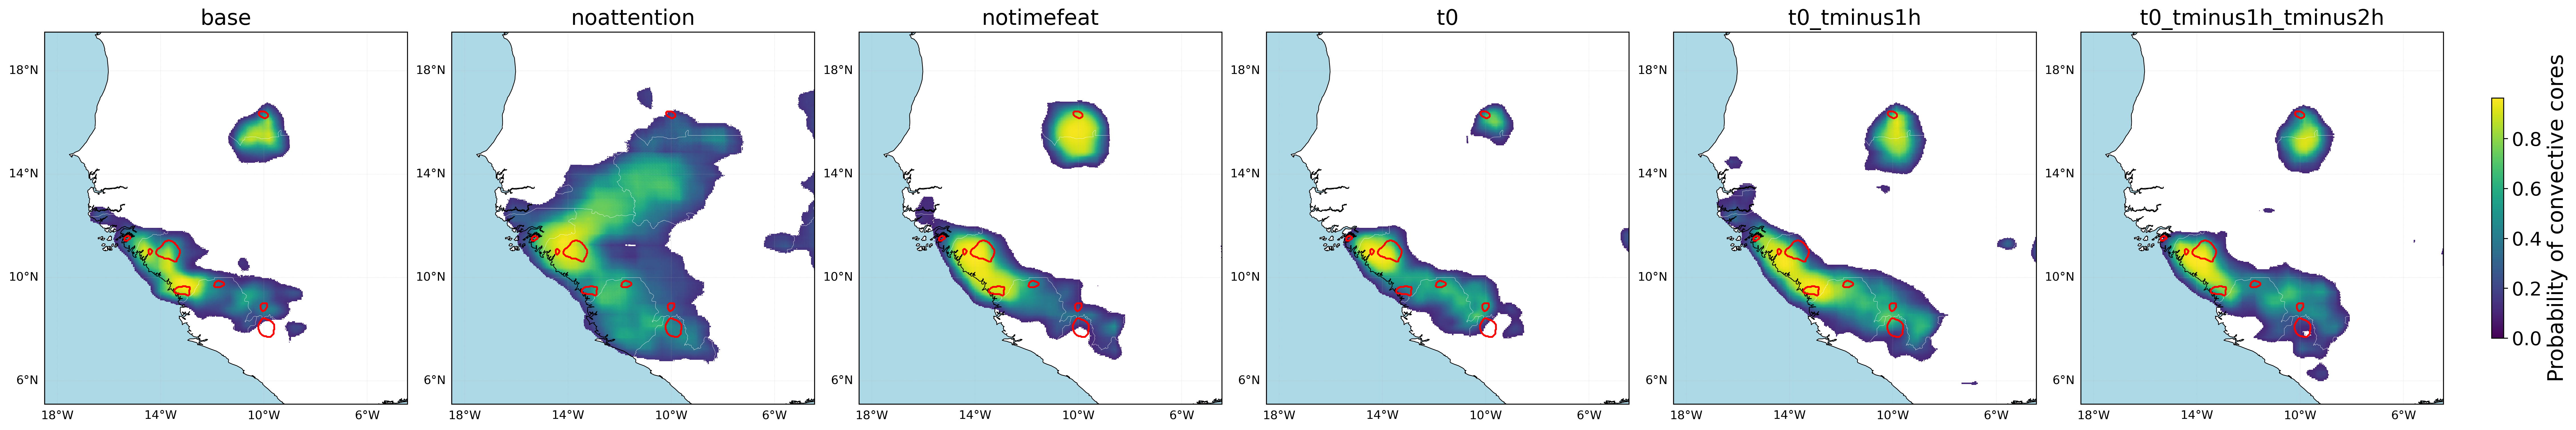

In [230]:
outputs = load_all_models(
    lead_time="1",
    year=year,
    month=month,
    day=day,
    hour=hour,
    minute=minute,
)

plot_all_model_nowcasts(outputs, "1", lons, lats)

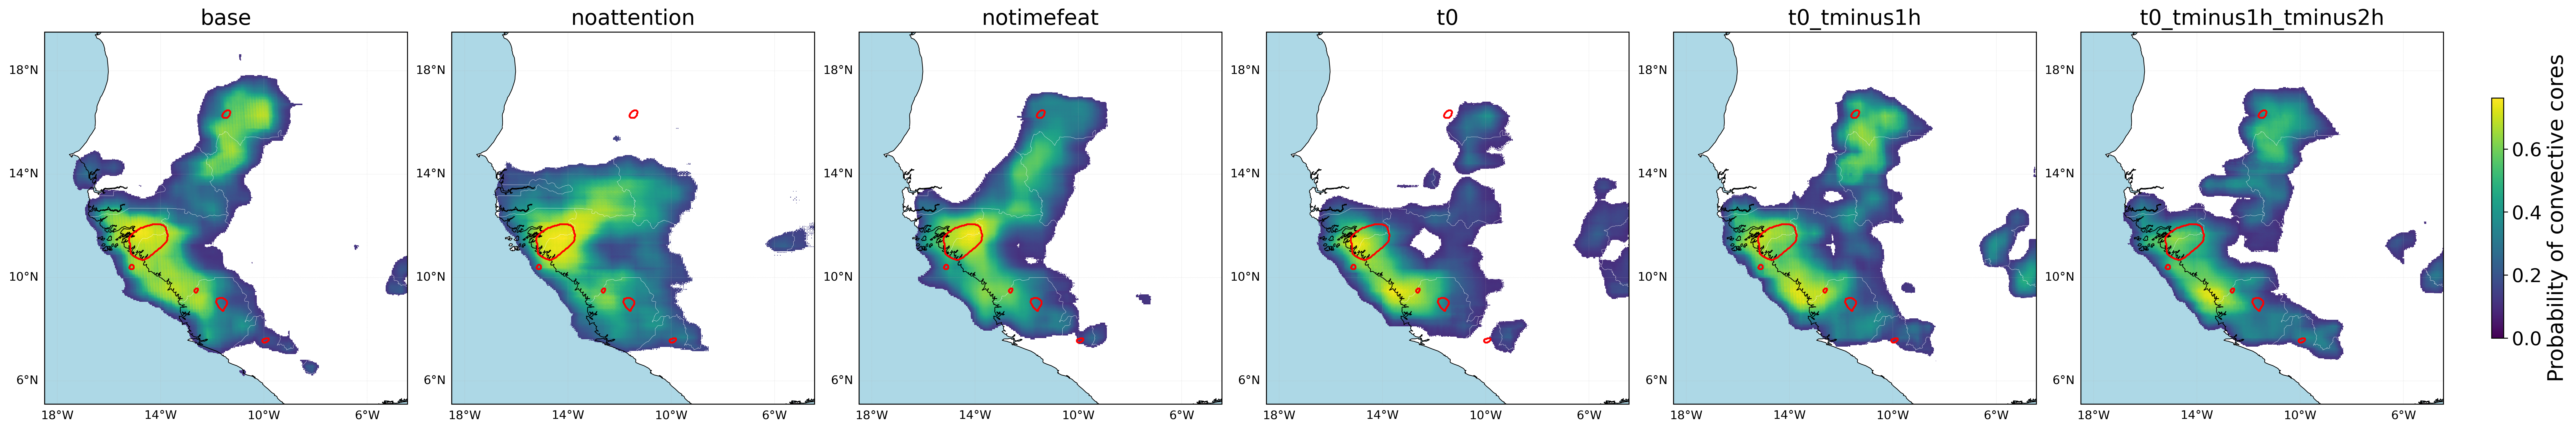

In [231]:
outputs = load_all_models(
    lead_time="3",
    year=year,
    month=month,
    day=day,
    hour=hour,
    minute=minute,
)

plot_all_model_nowcasts(outputs, "3", lons, lats)

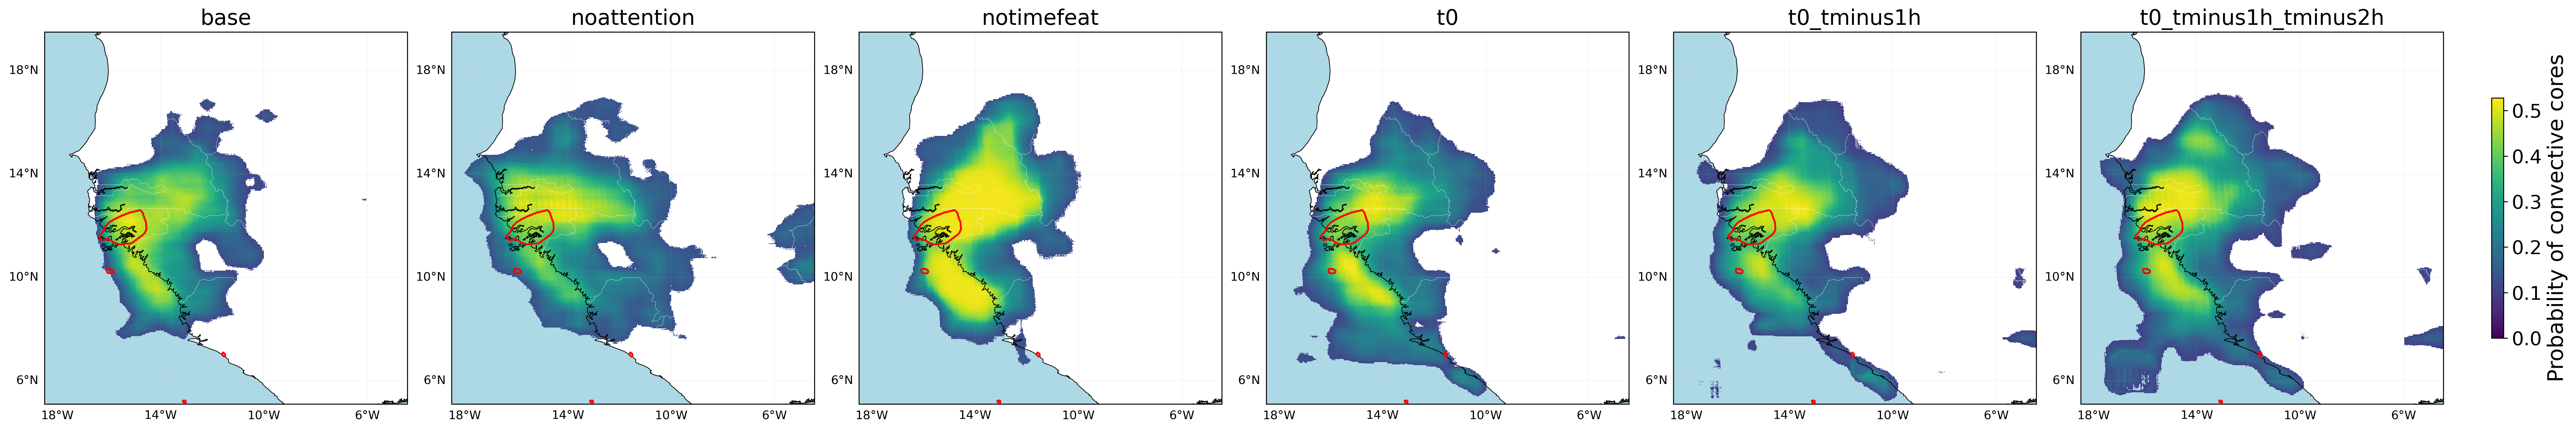

In [232]:
outputs = load_all_models(
    lead_time="6",
    year=year,
    month=month,
    day=day,
    hour=hour,
    minute=minute,
)

plot_all_model_nowcasts(outputs, "6", lons, lats)